# Phase 1 — Adaptive cyber-physical anomaly detection

Semi-supervised intrusion-style scoring: models fit on **benign** traffic only; evaluation uses a held-out mix of normal and attack-like points.

**Run order:** use *Run All* or `jupyter nbconvert --execute` so every cell below produces stored outputs.

## Environment

From the project root (parent of `notebooks/`):

```bash
python3 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt -r requirements-notebooks.txt
```

The next cell adds `src/` to `sys.path` so `cps_ad` imports work when the kernel cwd is `notebooks/`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from cps_ad.data import load_kddcup99_sa
from cps_ad.phase1 import results_to_markdown_table, run_phase1, write_json
from cps_ad.preprocess import apply_log1p_columns, numeric_skewness
from cps_ad.synthetic_data import load_synthetic_intrusion_sa_like

sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

print("Project root:", ROOT)
print("Python:", sys.executable)

Project root: /Users/kartikyadav/Desktop/Newtypeorgs/dl-aml-cybersec-project
Python: /Users/kartikyadav/Desktop/Newtypeorgs/dl-aml-cybersec-project/.venv/bin/python3.12


## Configuration

- Set `USE_SYNTHETIC = True` when sklearn cannot download KDDCup99 (SSL/air-gapped).
- Set `USE_SYNTHETIC = False` for the real **KDDCup99 SA** subset (first run may download data).

In [2]:
USE_SYNTHETIC = True  # set False for real KDDCup99 via sklearn
RANDOM_STATE = 42
PERCENT10 = True  # ignored when USE_SYNTHETIC is True
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

USE_SYNTHETIC, RANDOM_STATE, PERCENT10

(True, 42, True)

## Load data

In [3]:
if USE_SYNTHETIC:
    x_raw, y = load_synthetic_intrusion_sa_like(random_state=RANDOM_STATE)
    dataset_name = "synthetic_intrusion_tabular"
else:
    x_raw, y = load_kddcup99_sa(percent10=PERCENT10, random_state=RANDOM_STATE)
    dataset_name = "kddcup99_sa"

display(Markdown(f"**Dataset:** `{dataset_name}`  \n**Samples:** {len(y):,}  \n**Features (raw):** {x_raw.shape[1]}"))
x_raw.head()

**Dataset:** `synthetic_intrusion_tabular`  
**Samples:** 15,500  
**Features (raw):** 34

,duration,src_bytes,dst_bytes,stat_0,stat_1,stat_2,stat_3,stat_4,stat_5,stat_6,...,stat_21,stat_22,stat_23,stat_24,stat_25,stat_26,stat_27,protocol_type,service,flag
0,4.194671,721.077323,570.813743,1.092634,-1.335963,1.081928,1.016185,-1.535524,-1.325658,-0.279505,...,-0.765258,1.246618,-0.043631,-0.804845,-0.806649,0.045891,-0.792304,udp,domain,S0
1,39.779948,851.795243,69.561480,0.326878,-0.516707,0.141037,1.648348,-1.197920,-1.142364,0.419132,...,-1.186833,0.961276,-0.672803,-0.210728,0.062049,0.104666,0.713925,tcp,other,SF
2,46.915963,284.405533,526.806405,0.874067,-0.382865,5.482633,1.195001,-2.292072,-2.662480,2.287081,...,-1.134519,1.537620,0.973816,-3.462830,-1.668172,-1.086961,-1.329524,icmp,other,S0
3,28.926392,515.192232,870.868870,0.881120,-0.651831,1.278351,0.823516,-2.190504,-1.078727,-0.211395,...,-1.226708,0.976219,-0.730630,0.051273,-0.715044,0.444217,0.672706,tcp,ftp,REJ
4,5.329956,229.126403,845.483367,1.672655,0.177594,6.020404,-0.550102,-2.395307,-3.982165,1.386128,...,-1.341923,1.984353,0.158961,-2.796044,-2.020890,-0.132105,-1.499016,icmp,http,S0


## EDA: balance, skew, and plots

Skewness motivates `log1p` on heavy-tailed numeric columns in the library pipeline.

In [4]:
labels = np.where(y == 0, "normal", "attack")
bal = pd.Series(labels).value_counts()
bal_frac = pd.Series(labels).value_counts(normalize=True)
print("Counts:\n", bal.to_string())
print("\nFractions:\n", bal_frac.to_string())

skew = numeric_skewness(x_raw)
print("\nTop skew (numeric):")
display(skew.head(12).to_frame("skew"))

Counts:
 normal    12000
attack     3500

Fractions:
 normal    0.774194
attack    0.225806

Top skew (numeric):


,skew
stat_2,1.290079
stat_7,1.227416
stat_18,1.184870
stat_12,1.143210
stat_20,1.130875
stat_11,1.101940
stat_23,1.091081
stat_6,1.054676
stat_13,1.042200
duration,1.011327


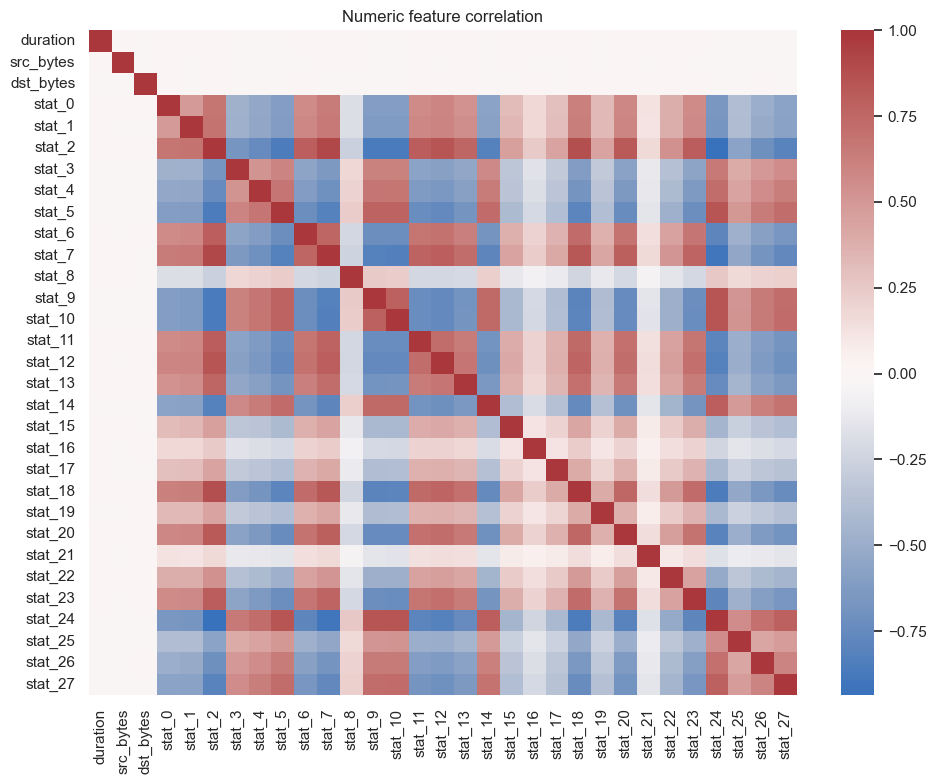

In [5]:
num = x_raw.select_dtypes(include=[np.number])
if len(num.columns) >= 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    corr = num.corr(numeric_only=True)
    sns.heatmap(corr, cmap="vlag", center=0.0, ax=ax)
    ax.set_title("Numeric feature correlation")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "nb_corr_numeric.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print("Skip correlation heatmap: fewer than 2 numeric columns.")

log1p applied to: ['stat_2', 'stat_7', 'stat_18', 'stat_12']
  stat_2: skew 1.290 -> 0.987
  stat_7: skew 1.227 -> 1.345
  stat_18: skew 1.185 -> 0.613
  stat_12: skew 1.143 -> 1.058


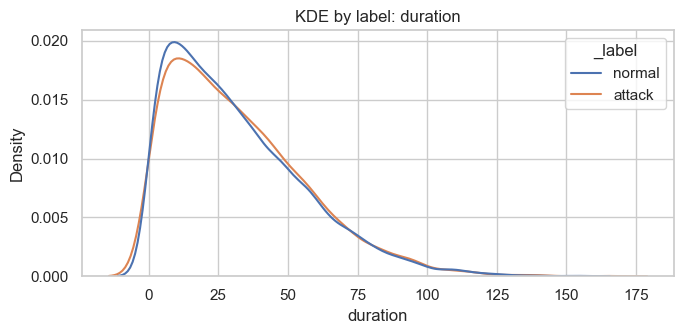

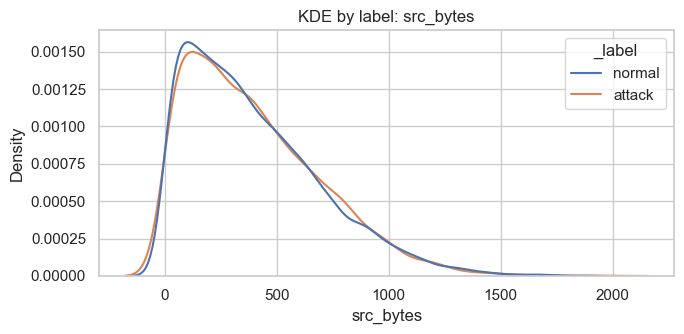

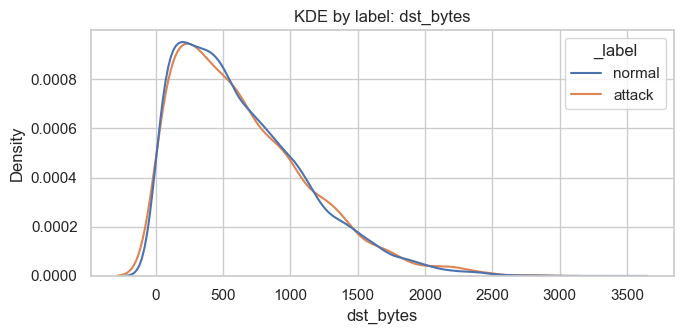

In [6]:
log_cols = list(skew.head(4).index)
x_fe, skew_reports = apply_log1p_columns(x_raw, log_cols)
print("log1p applied to:", log_cols)
for s in skew_reports:
    print(f"  {s.column}: skew {s.skew_before:.3f} -> {s.skew_after:.3f}")

sample_cols = [c for c in ["duration", "src_bytes", "dst_bytes", "count"] if c in x_fe.columns]
if not sample_cols:
    sample_cols = list(x_fe.select_dtypes(include=[np.number]).columns[:4])

for c in sample_cols[:3]:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    plot_df = x_fe[[c]].copy()
    plot_df["_label"] = labels
    sns.kdeplot(data=plot_df, x=c, hue="_label", common_norm=False, ax=ax)
    ax.set_title(f"KDE by label: {c}")
    plt.tight_layout()
    safe = str(c).replace("/", "_")
    fig.savefig(FIG_DIR / f"nb_kde_{safe}.png", dpi=140, bbox_inches="tight")
    plt.show()

## Phase 1 training and evaluation

Runs: max-|z| baseline, Ledoit–Wolf Mahalanobis, BIC-selected GMM NLL, One-Class SVM. Threshold tuned on validation F1; test metrics below.

In [7]:
results, meta = run_phase1(
    percent10=PERCENT10,
    random_state=RANDOM_STATE,
    synthetic=USE_SYNTHETIC,
)

display(Markdown("### Metadata"))
print(json.dumps(meta, indent=2, default=str))

table_md = results_to_markdown_table(results)
display(Markdown("### Results (Markdown table)"))
display(Markdown(table_md))

rows = [
    {
        "name": r.name,
        "val_threshold": r.val_threshold,
        "val_f1_at_threshold": r.val_f1_at_threshold,
        "test": r.test.__dict__,
    }
    for r in results
]
out_json = ROOT / "reports" / "phase1_metrics.json"
write_json(out_json, {"meta": meta, "rows": rows})
print("Wrote:", out_json)

### Metadata

{
  "dataset": "synthetic_intrusion_tabular",
  "synthetic": true,
  "percent10": true,
  "random_state": 42,
  "log1p_columns": [
    "stat_2",
    "stat_7",
    "stat_18",
    "stat_12"
  ],
  "skew_reports": [
    {
      "column": "stat_2",
      "skew_before": 1.2900793207071841,
      "skew_after": 0.9873622434282551
    },
    {
      "column": "stat_7",
      "skew_before": 1.2274164464136497,
      "skew_after": 1.3451635470717884
    },
    {
      "column": "stat_18",
      "skew_before": 1.1848704433655595,
      "skew_after": 0.6134254537038226
    },
    {
      "column": "stat_12",
      "skew_before": 1.1432097443668567,
      "skew_after": 1.0579568032599884
    }
  ],
  "gmm_bic_by_k": {
    "2": 507028.97665214876,
    "3": 459090.97613746306,
    "4": 380428.19912256696,
    "5": 360973.6698904357,
    "6": 297753.98385920265,
    "7": 278112.96098426526,
    "8": 225611.6359831414
  },
  "gmm_selected_k": 8,
  "class_balance": {
    "train": {
      "normal": 7650,

### Results (Markdown table)

| Model | Val F1 (thr tuned) | Test ROC-AUC | Test PR-AUC | Test F1 | Test Precision | Test Recall | Threshold |
|---|---:|---:|---:|---:|---:|---:|---:|
| baseline_max_zscore | 1.0000 | 1.0000 | 1.0000 | 0.9977 | 1.0000 | 0.9954 | 8.70413 |
| advanced_mahalanobis_shrunk | 1.0000 | 1.0000 | 1.0000 | 0.9960 | 1.0000 | 0.9920 | 470.84 |
| advanced_gmm_nll | 1.0000 | 1.0000 | 1.0000 | 0.9971 | 1.0000 | 0.9943 | 207.714 |
| advanced_one_class_svm | 1.0000 | 1.0000 | 1.0000 | 0.9954 | 1.0000 | 0.9909 | 27.4934 |

Wrote: /Users/kartikyadav/Desktop/Newtypeorgs/dl-aml-cybersec-project/reports/phase1_metrics.json


## Results as a DataFrame

In [8]:
rows_df = []
for r in results:
    d = {"model": r.name, "val_f1": r.val_f1_at_threshold, "threshold": r.val_threshold}
    d.update({f"test_{k}": v for k, v in r.test.__dict__.items() if k != "threshold"})
    rows_df.append(d)
pd.DataFrame(rows_df)

,model,val_f1,threshold,test_roc_auc,test_pr_auc,test_f1,test_precision,test_recall
0,baseline_max_zscore,1.0,8.704129,0.999999,0.999996,0.997709,1.0,0.995429
1,advanced_mahalanobis_shrunk,1.0,470.840128,1.000000,1.000000,0.995984,1.0,0.992000
2,advanced_gmm_nll,1.0,207.713705,1.000000,1.000000,0.997135,1.0,0.994286
3,advanced_one_class_svm,1.0,27.493423,1.000000,1.000000,0.995408,1.0,0.990857
